## Outlier

- What is an outlier?
    - Any value that does not belong to the data
        - is too large
        - or too small
        - too far from the mean

In [35]:
import numpy as np
import pandas as pd

# Sample dataset of e-commerce transactions
# Create a dictionary of multiple data items
data = [
    {"ID": 1001, "Name": "Alice Smith",  "Email": "alice@example.com",        "Product": "Laptop",     "Quantity": 1,    "Price": 1200.00, "Purchase Date": "2024-09-15",   "Delivery Status": True},
    {"ID": 1002, "Name": "Bob Jones",    "Email": None,                       "Product": "Headphones", "Quantity": 2,    "Price": 150.00,  "Purchase Date": "2024-09-16",   "Delivery Status": True},
    {"ID": 1003, "Name": "Charlie John", "Email": "charlie#example.com",      "Product": "Smartphone", "Quantity": 1,    "Price": 800.00,  "Purchase Date": "16/09/2024",   "Delivery Status": True},
    {"ID": 1004, "Name": "David Lee",    "Email": "david.lee@example.com",    "Product": "Laptop",     "Quantity": 1,    "Price": 1200.00, "Purchase Date": "2024-09-17",   "Delivery Status": False},
    {"ID": 1005, "Name": "Eve Martinez", "Email": "eve.martinez@example.com", "Product": "Smartwatch", "Quantity": 3,    "Price": 600.00,    "Purchase Date": "17th Sep 2024","Delivery Status": True},
    {"ID": 1006, "Name": "Frank Wright", "Email": None,                       "Product": "Tablet",     "Quantity": 1,    "Price": 600.00,  "Purchase Date": "2024-09-18",   "Delivery Status": False},
    {"ID": 1007, "Name": "Grace Lee",    "Email": "grace.lee@example.com",    "Product": "Laptop",     "Quantity": 1,    "Price": 12000.00, "Purchase Date": "2024-09-19",   "Delivery Status": True},
    {"ID": 1008, "Name": "Hank Brown",   "Email": "hank.brown@example.com",   "Product": "Monitor",    "Quantity": 2,    "Price": 300.00,  "Purchase Date": "09/19/2024",   "Delivery Status": True},
    {"ID": 1009, "Name": "Ivy Thompson", "Email": None,                       "Product": "Keyboard",   "Quantity": 2,    "Price": 100.00,  "Purchase Date": "2024/09/20",   "Delivery Status": False},
    {"ID": 1010, "Name": "Jack Davis",   "Email": "jack@example.com",         "Product": "Mouse",      "Quantity": 5,    "Price": 50.00,   "Purchase Date": "2024-09-21",   "Delivery Status": True},
    {"ID": 1011, "Name": "Alice Smith",  "Email": "alice@example.com",        "Product": "Laptop",     "Quantity": 1,    "Price": 1200.00, "Purchase Date": "2024-09-15",   "Delivery Status": True},  # Duplicate entry
    {"ID": 1012, "Name": "Kurt Evans",   "Email": "kurt.evans@example.com",   "Product": "Smartwatch", "Quantity": 100,   "Price": 200.00,  "Purchase Date": "2024-09-22",   "Delivery Status": True},  # Outlier quantity
    {"ID": 1013, "Name": "Liam Adams",   "Email": "liam.adams@example.com",   "Product": "Headphones", "Quantity": 2,    "Price": 150.00,  "Purchase Date": "2024-09-23",   "Delivery Status": False},
    {"ID": 1014, "Name": "Mia Clark",    "Email": "mia.clark@example.com",    "Product": None,         "Quantity": 1,    "Price": 0,       "Purchase Date": "2024-09-24",   "Delivery Status": True},  # Price anomaly
    {"ID": 1015, "Name": "Nina Turner",  "Email": None,                       "Product": "Tablet",     "Quantity": 1,    "Price": 600.00,  "Purchase Date": "24-09-2024",   "Delivery Status": True},
    {"ID": 1016, "Name": "Oscar Harris", "Email": "oscar.harris@example.com", "Product": "Laptop",     "Quantity": 2,    "Price": 1200.00, "Purchase Date": "2024-09-25",   "Delivery Status": True},
    {"ID": 1017, "Name": "Paul Young",   "Email": "paulyoung",                "Product": "Monitor",    "Quantity": 2,    "Price": 300.00,  "Purchase Date": "09/25/2024",   "Delivery Status": True},
    {"ID": 1018, "Name": "Quinn Lopez",  "Email": None,                       "Product": "Smartphone", "Quantity": 1,    "Price": 800.00,  "Purchase Date": "2024-09-26",   "Delivery Status": False},
    {"ID": 1019, "Name": "Rachel Scott", "Email": "rachel.scott@example.com", "Product": "Keyboard",   "Quantity": 2,    "Price": 100.00,  "Purchase Date": "2024-09-27",   "Delivery Status": True},
    {"ID": 1020, "Name": "Steve King",   "Email": "steve.king@example.com",   "Product": "Mouse",      "Quantity": 5, "Price": 50.00,   "Purchase Date": "2024-09-28",   "Delivery Status": True},
]

# Displaying the dataset
import pandas as pd

# Convert the list of dictionaries to a DataFrame for easier visualization and manipulation
df = pd.DataFrame(data)
df.head()

,ID,Name,Email,Product,Quantity,Price,Purchase Date,Delivery Status
0,1001,Alice Smith,alice@example.com,Laptop,1,1200.0,2024-09-15,True
1,1002,Bob Jones,NaN,Headphones,2,150.0,2024-09-16,True
2,1003,Charlie John,charlie#example.com,Smartphone,1,800.0,16/09/2024,True
3,1004,David Lee,david.lee@example.com,Laptop,1,1200.0,2024-09-17,False
4,1005,Eve Martinez,eve.martinez@example.com,Smartwatch,3,600.0,17th Sep 2024,True


In [41]:
import seaborn as sns

data = pd.Series([20, 20, 20, 25, 25, 30, 100, 30, 30, 35, 40, 45, 50, 70])

data.median()

# sns.histplot(data, bins = 10)

data.describe()

data.quantile(0) # min
Q1 = data.quantile(0.25) # First Quartile
data.quantile(0.50) # Second Quartile # median
Q3 = data.quantile(0.75) # Third Quartile
data.quantile(1) # max


IQR = Q3 - Q1

# IQR method of outlier detection
lower = Q1 - IQR * 1.5
upper = Q3 + IQR * 1.5

print(lower, upper)

# filter out the outliers
outliers = data[(data < lower) | (data> upper)]
outliers

-3.125 71.875


6    100
dtype: int64

![](https://tse2.mm.bing.net/th/id/OIP.kzGqWt1HYs65-erFCvW8AwHaE-?r=0&rs=1&pid=ImgDetMain&o=7&rm=3)

![](https://tse3.mm.bing.net/th/id/OIP.wYZtibYLJpvxTa9jrVSH9QHaEw?r=0&rs=1&pid=ImgDetMain&o=7&rm=3)

<Axes: >

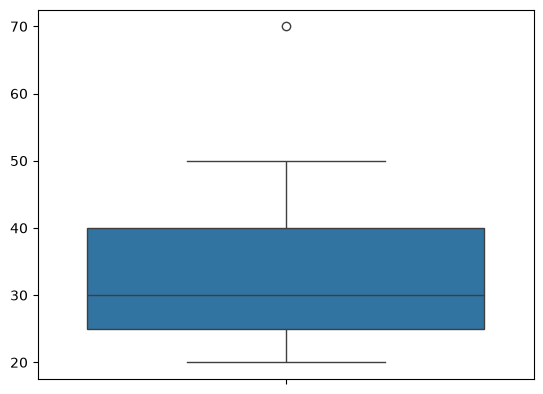

In [34]:
sns.boxplot(data)

<Axes: >

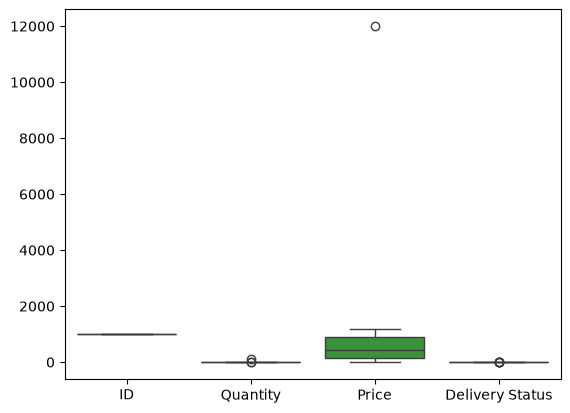

In [ ]:
df2 = df.copy()

sns.boxplot(df2)
# price has an outlier

### IQR method of Outlier Removal

Inter Qurartile Range:
- IQR = Q3 - Q1

- to define normal data:
    - we decide what the lower bound and upper bound should be
    - anything beyond is an outlier

- lower = Q1 - 1.5 * IQR

- upper = Q3 + 1.5 * IQR



In [ ]:
# Exercise
# Detect and remove the outlier from the df2 price
